# Boucle Fermee v2 — LSTM (latence) + MILP

## Corrections v2
- **Option A** : la loss est derivee de la **latence predite** par le LSTM (pas de la colonne loss qui etait 0 partout)
  `p_pred = fraction(lat_pred_ms > SLA_max)`
- **Architecture** : boucle par `(gnb, scenario)` — les 3 slices sont predites simultanement
  → le MILP recoit rho_pred coherent pour toutes les slices en meme temps

## Pipeline
```
Pour chaque fenetre de 15s :
  Pour chaque slice (eMBB, URLLC, mMTC) :
    [30s historique] → LSTM → pred_latency_log1p (15 pas)
                                   ↓
               lat_pred_ms = expm1(pred_latency)
                                   ↓
               p_pred = fraction(lat_pred_ms > SLA_max)
                                   ↓
               rho_pred = inverse_sigmoid(p_pred)
  ↓
  MILP(rho_eMBB, rho_URLLC, rho_mMTC) → R_optimal
  ↓
  F(R_default) vs F(R_optimal) sur la fenetre suivante
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle, os, time, warnings
from scipy.optimize import curve_fit, milp, LinearConstraint, Bounds
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

CSV_PATH   = 'all_simu5g_trans.csv'
MODELS_DIR = 'models_lstm_v3'
OUT_DIR    = '../output/'
os.makedirs(OUT_DIR, exist_ok=True)

INPUT_SEC   = 60
OUTPUT_SEC  = 15
N_IN        = 15
N_OUT       = 3
HIDDEN_SIZE = 256
NUM_LAYERS  = 3
DROPOUT     = 0.25
ENG_WINDOW  = 5
LAT_IDX     = 1   # index latence dans la sortie LSTM (throughput=0, latency_log1p=1, loss=2)

FEATURES_PROC = ['Slice_Throughput_Mbps', 'Slice_Latency_log1p',
                 'Slice_Packet_Loss_pct', 'Slice_Jitter_log1p',
                 'Slice_Network_Load_pct']

DEFAULT_RBS = {
    'Macro':     {'eMBB': 20, 'URLLC': 17, 'mMTC': 13},
    'Commerce':  {'eMBB': 21, 'URLLC': 11, 'mMTC':  3},
    'Industrie': {'eMBB':  6, 'URLLC': 12, 'mMTC':  7},
}
R_MAX    = {'Macro': 50, 'Commerce': 35, 'Industrie': 25}
R_PER_RB = {
    'Macro':     {'eMBB': 0.560, 'URLLC': 0.125, 'mMTC': 0.050},
    'Commerce':  {'eMBB': 0.229, 'URLLC': 0.097, 'mMTC': 0.050},
    'Industrie': {'eMBB': 0.400, 'URLLC': 0.195, 'mMTC': 0.050},
}
SLA_OPT = {
    'eMBB':  {'T_min': 10.0,    'L_max_ms':  60.0},   # dataset=50ms, SLA_DETECT=60ms
    'URLLC': {'T_min':  0.5,    'L_max_ms':  25.0},   # dataset=20ms, SLA_DETECT=25ms
    'mMTC':  {'T_min':  0.0003, 'L_max_ms': 300.0},   # correction 3GPP (8.8->300ms)
}
OMEGA_T = 0.6
OMEGA_P = 0.4
SLICES  = ['eMBB', 'URLLC', 'mMTC']
GNBS    = ['Macro', 'Commerce', 'Industrie']
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')


Device : cuda


## 1. Architecture LSTM

In [2]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_dim, dec_dim, attn_dim=128):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v     = nn.Linear(attn_dim, 1, bias=False)
    def forward(self, enc_out, dec_hidden):
        energy = self.v(torch.tanh(
            self.W_enc(enc_out) + self.W_dec(dec_hidden).unsqueeze(1)
        )).squeeze(-1)
        attn_w  = F.softmax(energy, dim=1)
        context = (attn_w.unsqueeze(-1) * enc_out).sum(1)
        return context, attn_w

class LSTMEncoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.proj_h      = nn.Linear(hidden_size * 2, hidden_size)
        self.proj_c      = nn.Linear(hidden_size * 2, hidden_size)
        self.num_layers  = num_layers
        self.hidden_size = hidden_size
    def forward(self, x):
        enc_out, (h, c) = self.lstm(x)
        h = h.view(self.num_layers, 2, -1, self.hidden_size)
        c = c.view(self.num_layers, 2, -1, self.hidden_size)
        h = torch.tanh(self.proj_h(torch.cat([h[:,0], h[:,1]], dim=-1)))
        c = torch.tanh(self.proj_c(torch.cat([c[:,0], c[:,1]], dim=-1)))
        return enc_out, h, c

class LSTMDecoder(nn.Module):
    def __init__(self, output_size, hidden_size, num_layers, dropout):
        super().__init__()
        enc_dim  = hidden_size * 2
        self.attn    = BahdanauAttention(enc_dim, hidden_size, 128)
        self.lstm    = nn.LSTM(output_size + enc_dim, hidden_size, num_layers,
                               batch_first=True,
                               dropout=dropout if num_layers > 1 else 0)
        self.fc_out  = nn.Linear(hidden_size + enc_dim, output_size)
        self.dropout = nn.Dropout(dropout)
    def forward_step(self, prev_pred, enc_out, h, c):
        context, _ = self.attn(enc_out, h[-1])
        lstm_in    = torch.cat([prev_pred, context], dim=1).unsqueeze(1)
        out_lstm, (h, c) = self.lstm(lstm_in, (h, c))
        out = self.fc_out(self.dropout(torch.cat([out_lstm.squeeze(1), context], dim=1)))
        return out, h, c

class Seq2Seq(nn.Module):
    def __init__(self, n_in, n_out, hidden_size, num_layers, dropout):
        super().__init__()
        self.encoder = LSTMEncoder(n_in, hidden_size, num_layers, dropout)
        self.decoder = LSTMDecoder(n_out, hidden_size, num_layers, dropout)
        self.n_out   = n_out
    def forward(self, src, tgt_len):
        enc_out, h, c = self.encoder(src)
        prev  = torch.zeros(src.size(0), self.n_out, device=src.device)
        preds = []
        for _ in range(tgt_len):
            out, h, c = self.decoder.forward_step(prev, enc_out, h, c)
            preds.append(out.unsqueeze(1))
            prev = out
        return torch.cat(preds, dim=1)

print('Architecture LSTM definie.')


Architecture LSTM definie.


## 2. Donnees + feature engineering

In [3]:
df_raw = pd.read_csv(CSV_PATH)
df_raw['Slice_Latency_log1p'] = np.log1p(df_raw['Slice_Latency_ms'].clip(0, 600_000))
df_raw['Slice_Jitter_log1p']  = np.log1p(df_raw['Slice_Jitter_ms'].clip(0,  600_000))
df_raw['SLA_Latency_Corr']    = df_raw['SLA_Latency_Max_ms'].copy()
df_raw.loc[df_raw['Slice_Type'] == 'mMTC', 'SLA_Latency_Corr'] = 300.0
df_raw['loss_binary'] = (df_raw['Slice_Latency_ms'] > df_raw['SLA_Latency_Corr']).astype(float)

def engineer_features(series, window=ENG_WINDOW):
    '''(T,5) -> (T,15) : [orig | trend | vol]'''
    trend    = np.zeros_like(series)
    trend[1:] = np.diff(series, axis=0)
    from numpy.lib.stride_tricks import sliding_window_view
    vol = np.zeros_like(series)
    if len(series) >= window:
        wins = sliding_window_view(series, window_shape=window, axis=0)
        vol[window-1:] = wins.std(axis=-1)
    return np.concatenate([series, trend, vol], axis=1)

# Pre-charger toutes les series pour eviter les queries repetees
print('Pre-chargement des series...')
series_cache  = {}   # (stype, gnb, scenario) -> raw (T,5)
loss_cache    = {}   # (stype, gnb, scenario) -> loss_binary (T,)

for scenario in df_raw['Scenario'].unique():
    for gnb in GNBS:
        for stype in SLICES:
            sub = df_raw[
                (df_raw['Slice_Type'] == stype) &
                (df_raw['gNB_id']     == gnb)   &
                (df_raw['Scenario']   == scenario)
            ].sort_values('Time_Sec')
            key = (stype, gnb, scenario)
            if len(sub) >= INPUT_SEC + OUTPUT_SEC:
                series_cache[key] = sub[FEATURES_PROC].values.astype(np.float32)
                loss_cache[key]   = sub['loss_binary'].values.astype(np.float32)

print(f'Series en cache : {len(series_cache)}')


Pre-chargement des series...
Series en cache : 150


## 3. Chargement des modeles LSTM

In [4]:
models  = {}
scalers = {}
for stype in SLICES:
    mp = os.path.join(MODELS_DIR, f"model_final_{stype}.pt")
    sp = os.path.join(MODELS_DIR, f"scalers_final_{stype}.pkl")
    if not os.path.exists(mp):
        print(f"  ABSENT : {mp}")
        continue
    model = Seq2Seq(N_IN, N_OUT, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
    model.load_state_dict(torch.load(mp, map_location=DEVICE, weights_only=False))
    model.eval()
    with open(sp, "rb") as fh:
        sc_all = pickle.load(fh)
    for gnb in GNBS:
        models[(stype, gnb)] = model
        sc_entry = sc_all[(stype, gnb)]
        scalers[(stype, gnb)] = {"src": sc_entry["x"], "tgt": sc_entry["y"]}
    print(f"  Charge : {stype:6s} -> partage sur {GNBS}")
print(f"Modeles : {len(models)} / 9")


  Charge : eMBB   -> partage sur ['Macro', 'Commerce', 'Industrie']
  Charge : URLLC  -> partage sur ['Macro', 'Commerce', 'Industrie']
  Charge : mMTC   -> partage sur ['Macro', 'Commerce', 'Industrie']
Modeles : 9 / 9


## 4. Calibration sigmoid

In [5]:
def sigmoid(rho, k, rho_c):
    return 1.0 / (1.0 + np.exp(-k * (rho - rho_c)))

def inv_sigmoid(p, k, rho_c):
    p = np.clip(float(p), 1e-6, 1 - 1e-6)
    return rho_c - np.log(1.0 / p - 1.0) / k

sigmoid_params = {}
for gnb in GNBS:
    for stype in SLICES:
        rows = []
        for scenario in df_raw['Scenario'].unique():
            key = (stype, gnb, scenario)
            if key not in loss_cache:
                continue
            p_lost = loss_cache[key].mean()
            tp     = series_cache[key][:, 0].mean()
            cap    = DEFAULT_RBS[gnb][stype] * R_PER_RB[gnb][stype]
            if p_lost >= 0.99:
                rho = 2.0
            elif p_lost > 0.01:
                rho = min(tp / max(cap * (1 - p_lost), 1e-6), 3.0)
            else:
                rho = tp / max(cap, 1e-6)
            rows.append((rho, p_lost))
        arr = np.array(rows)
        try:
            popt, _ = curve_fit(sigmoid, arr[:,0], arr[:,1],
                                p0=[5.0, 1.0], bounds=([0.5, 0.05],[50.0, 3.0]),
                                maxfev=10000)
            sigmoid_params[(gnb, stype)] = tuple(popt)
        except Exception:
            sigmoid_params[(gnb, stype)] = (5.0, 1.0)

print('Sigmoid calibree :')
for (gnb, stype), (k, rc) in sorted(sigmoid_params.items()):
    print(f'  {gnb:12s} {stype:6s}  k={k:.2f}  rho_c={rc:.3f}')


Sigmoid calibree :
  Commerce     URLLC   k=15.27  rho_c=0.406
  Commerce     eMBB    k=5.93  rho_c=1.404
  Commerce     mMTC    k=10.51  rho_c=1.245
  Industrie    URLLC   k=4.67  rho_c=1.307
  Industrie    eMBB    k=1.33  rho_c=2.304
  Industrie    mMTC    k=11.88  rho_c=1.444
  Macro        URLLC   k=2.91  rho_c=1.093
  Macro        eMBB    k=4.68  rho_c=0.798
  Macro        mMTC    k=10.50  rho_c=1.245


## 5. Inference LSTM — Option A : latence predite

On utilise `pred[:, LAT_IDX]` (latence log1p) pour decider si un paquet est perdu :
```
lat_pred_ms = expm1(lat_pred_log1p)
p_pred      = mean(lat_pred_ms > SLA_max)   ← fraction de pas en violation
rho_pred    = inv_sigmoid(p_pred)
```


In [6]:
def predict_rho(stype, gnb, history_raw):
    '''
    history_raw : (INPUT_SEC, 5)
    Retourne    : rho_pred (float) estime depuis la latence predite
    '''
    key = (stype, gnb)
    if key not in models:
        return 0.1, 0.0, 0.0

    sc_src = scalers[key]['src']
    sc_tgt = scalers[key]['tgt']

    feat_eng  = engineer_features(history_raw)          # (30, 15)
    feat_norm = sc_src.transform(feat_eng)
    x = torch.tensor(feat_norm, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_norm = models[key](x, OUTPUT_SEC).squeeze(0).cpu().numpy()  # (15, 3)

    pred = sc_tgt.inverse_transform(pred_norm)          # (15, 3) denormalise

    # --- Option A : latence predite -> binary loss -> rho ---
    lat_pred_log1p = pred[:, LAT_IDX]
    lat_pred_ms    = np.expm1(lat_pred_log1p)           # retour en ms
    SLA_lat        = SLA_OPT[stype]['L_max_ms']
    p_pred         = float((lat_pred_ms > SLA_lat).mean())   # fraction predite perdue

    # Estimation rho depuis p_pred
    k_s, rc = sigmoid_params[(gnb, stype)]
    if p_pred >= 0.99:
        rho_pred = 2.0
    elif p_pred > 0.01:
        rho_pred = float(np.clip(inv_sigmoid(p_pred, k_s, rc), 0.01, 3.0))
    else:
        # Pas de perte predite : rho depuis throughput predit
        tp_pred  = max(float(pred[:, 0].mean()), 0.0)
        cap      = DEFAULT_RBS[gnb][stype] * R_PER_RB[gnb][stype]
        rho_pred = float(np.clip(tp_pred / max(cap, 1e-6), 0.01, 3.0))

    return rho_pred, p_pred, lat_pred_ms.mean()

# --- Test ---
key_test = ('eMBB', 'Macro', 'NormalLoad')
if key_test in series_cache:
    hist  = series_cache[key_test][:INPUT_SEC]
    rho_p, p_p, lat_p = predict_rho('eMBB', 'Macro', hist)
    print(f'Test eMBB/Macro/NormalLoad :')
    print(f'  rho_pred       = {rho_p:.4f}')
    print(f'  p_pred (loss)  = {p_p:.4f}')
    print(f'  lat_pred (moy) = {lat_p:.2f} ms  (SLA = {SLA_OPT["eMBB"]["L_max_ms"]} ms)')

key_test2 = ('eMBB', 'Macro', 'GlobalSaturation')
if key_test2 in series_cache:
    hist2 = series_cache[key_test2][:INPUT_SEC]
    rho_p2, p_p2, lat_p2 = predict_rho('eMBB', 'Macro', hist2)
    print(f'\nTest eMBB/Macro/GlobalSaturation :')
    print(f'  rho_pred       = {rho_p2:.4f}  (attendu >= 1.0)')
    print(f'  p_pred (loss)  = {p_p2:.4f}  (attendu proche de 1.0)')
    print(f'  lat_pred (moy) = {lat_p2:.2f} ms')


Test eMBB/Macro/NormalLoad :
  rho_pred       = 0.3885
  p_pred (loss)  = 0.0000
  lat_pred (moy) = 18.63 ms  (SLA = 60.0 ms)

Test eMBB/Macro/GlobalSaturation :
  rho_pred       = 2.0000  (attendu >= 1.0)
  p_pred (loss)  = 1.0000  (attendu proche de 1.0)
  lat_pred (moy) = 401.64 ms


## 6. MILP adaptatif

In [7]:
def compute_costs_from_rho(gnb, rho_dict):
    costs = {}
    for stype in SLICES:
        rho_base = rho_dict.get(stype, 0.1)
        lam      = rho_base * DEFAULT_RBS[gnb][stype] * R_PER_RB[gnb][stype]
        k_s, rc  = sigmoid_params[(gnb, stype)]
        R_def    = DEFAULT_RBS[gnb][stype]
        T_min    = SLA_OPT[stype]['T_min']
        for k in range(1, R_MAX[gnb] + 1):
            rho_k = rho_base * R_def / k
            p_s   = float(np.clip(sigmoid(rho_k, k_s, rc), 0.0, 1.0))
            cap_k = k * R_PER_RB[gnb][stype]
            T_s   = min(lam, cap_k) * (1.0 - p_s)
            pen_T = max(0.0, 1.0 - T_s / T_min) if (lam >= T_min and T_min > 0) else 0.0
            costs[(stype, k)] = OMEGA_T * pen_T + OMEGA_P * p_s
    return costs

def solve_milp_from_costs(gnb, costs):
    R, n_sl  = R_MAX[gnb], len(SLICES)
    n_vars   = n_sl * R
    c        = np.array([costs[(SLICES[si], k)]
                         for si in range(n_sl) for k in range(1, R+1)])
    n_eq = n_sl + 1
    A_eq = np.zeros((n_eq, n_vars))
    for si in range(n_sl):
        for k in range(1, R+1):
            A_eq[si,   si*R+(k-1)] = 1.0
            A_eq[n_sl, si*R+(k-1)] = float(k)
    b_eq = np.array([1.0]*n_sl + [float(R)])
    result = milp(c, constraints=LinearConstraint(A_eq, lb=b_eq, ub=b_eq),
                  integrality=np.ones(n_vars), bounds=Bounds(0.0, 1.0))
    if result.success:
        best_R = {}
        for si, stype in enumerate(SLICES):
            for k in range(1, R+1):
                if result.x[si*R+(k-1)] > 0.5:
                    best_R[stype] = k
                    break
        return best_R, result.fun
    return DEFAULT_RBS[gnb].copy(), sum(costs[(s, DEFAULT_RBS[gnb][s])] for s in SLICES)

def f_from_rho(gnb, R_vec, rho_dict):
    total = 0.0
    for stype in SLICES:
        rho_base = rho_dict.get(stype, 0.1)
        lam      = rho_base * DEFAULT_RBS[gnb][stype] * R_PER_RB[gnb][stype]
        k_s, rc  = sigmoid_params[(gnb, stype)]
        R_s      = max(R_vec[stype], 1)
        rho_k    = rho_base * DEFAULT_RBS[gnb][stype] / R_s
        p_s      = float(np.clip(sigmoid(rho_k, k_s, rc), 0.0, 1.0))
        cap_k    = R_s * R_PER_RB[gnb][stype]
        T_s      = min(lam, cap_k) * (1.0 - p_s)
        T_min    = SLA_OPT[stype]['T_min']
        pen_T    = max(0.0, 1.0 - T_s / T_min) if (lam >= T_min and T_min > 0) else 0.0
        total   += OMEGA_T * pen_T + OMEGA_P * p_s
    return total

print('MILP adaptatif defini.')


MILP adaptatif defini.


## 7. Boucle fermee par (gNB, scenario)

Pour chaque fenetre de 15s :
1. Predire la latence pour les 3 slices simultanement
2. Estimer rho_pred pour chaque slice depuis la latence predite
3. MILP avec les 3 rho → R_optimal global
4. Comparer F(R_default) vs F(R_optimal)


In [8]:
TRAIN_RATIO = 0.80   # evaluation uniquement sur les 20% test (jamais vus a l'entrainement)

def run_closed_loop_gnb(gnb, scenario):
    series = {}
    losses = {}
    T_min_len = None
    for stype in SLICES:
        key = (stype, gnb, scenario)
        if key not in series_cache:
            return None
        series[stype] = series_cache[key]
        losses[stype] = loss_cache[key]
        T = len(series[stype])
        T_min_len = T if T_min_len is None else min(T_min_len, T)

    if T_min_len is None or T_min_len < INPUT_SEC + OUTPUT_SEC:
        return None

    # Demarre au debut du split test (20% finaux) pour evaluer uniquement sur donnees non vues
    cut = int(T_min_len * TRAIN_RATIO)
    t   = max(INPUT_SEC, cut)   # besoin d'au moins INPUT_SEC de contexte

    records = []
    while t + OUTPUT_SEC <= T_min_len:
        rho_dict      = {}
        p_pred_dict   = {}
        lat_pred_dict = {}

        for stype in SLICES:
            history = series[stype][t - INPUT_SEC : t]
            rho_p, p_p, lat_p = predict_rho(stype, gnb, history)
            rho_dict[stype]      = rho_p
            p_pred_dict[stype]   = p_p
            lat_pred_dict[stype] = lat_p

        costs        = compute_costs_from_rho(gnb, rho_dict)
        R_opt, F_opt = solve_milp_from_costs(gnb, costs)
        F_def        = f_from_rho(gnb, DEFAULT_RBS[gnb], rho_dict)

        loss_real = {stype: losses[stype][t : t + OUTPUT_SEC].mean() for stype in SLICES}

        # Taux de violation SLA estime sous allocation MILP (via modele sigmoid calibre)
        # p_sla_opt[s] = sigmoid(rho_s * R_def_s / R_opt_s) — risque de violation si on applique R_opt
        p_sla_opt = {}
        for stype in SLICES:
            k_s, rc   = sigmoid_params[(gnb, stype)]
            R_def_s   = DEFAULT_RBS[gnb][stype]
            R_opt_s   = max(R_opt.get(stype, R_def_s), 1)
            rho_opt_s = rho_dict[stype] * R_def_s / R_opt_s
            p_sla_opt[stype] = float(np.clip(sigmoid(rho_opt_s, k_s, rc), 0.0, 1.0))

        records.append({
            't':               t,
            'F_default':       round(F_def, 4),
            'F_optimal':       round(F_opt, 4),
            'gain_pct':        round((F_def - F_opt) / max(F_def, 1e-9) * 100, 1),
            'rho_eMBB':        round(rho_dict['eMBB'],  4),
            'rho_URLLC':       round(rho_dict['URLLC'], 4),
            'rho_mMTC':        round(rho_dict['mMTC'],  4),
            'p_pred_eMBB':     round(p_pred_dict['eMBB'],  4),
            'p_pred_URLLC':    round(p_pred_dict['URLLC'], 4),
            'p_pred_mMTC':     round(p_pred_dict['mMTC'],  4),
            'p_real_eMBB':     round(loss_real['eMBB'],  4),
            'p_real_URLLC':    round(loss_real['URLLC'], 4),
            'p_real_mMTC':     round(loss_real['mMTC'],  4),
            'p_sla_opt_eMBB':  round(p_sla_opt['eMBB'],  4),
            'p_sla_opt_URLLC': round(p_sla_opt['URLLC'], 4),
            'p_sla_opt_mMTC':  round(p_sla_opt['mMTC'],  4),
            'R_eMBB_opt':      R_opt.get('eMBB',  0),
            'R_URLLC_opt':     R_opt.get('URLLC', 0),
            'R_mMTC_opt':      R_opt.get('mMTC',  0),
        })
        t += OUTPUT_SEC

    return pd.DataFrame(records) if records else None

print(f'Boucle fermee definie — evaluation sur 20% test uniquement (cut={int(1800*TRAIN_RATIO)}s / serie)')

Boucle fermee definie — evaluation sur 20% test uniquement (cut=1440s / serie)


## 8. Execution sur tous les scenarios

In [9]:
all_results = []
t0 = time.time()

for scenario in sorted(df_raw['Scenario'].unique()):
    for gnb in GNBS:
        df_loop = run_closed_loop_gnb(gnb, scenario)
        if df_loop is not None and len(df_loop) > 0:
            df_loop['scenario'] = scenario
            df_loop['gnb']      = gnb
            all_results.append(df_loop)

df_all = pd.concat(all_results, ignore_index=True)
elapsed = time.time() - t0
df_all.to_csv(OUT_DIR + 'closed_loop_v2_results.csv', index=False)

print(f'Simulation : {elapsed:.1f}s  |  Fenetres : {len(df_all):,}')
print()
print('=== Resume global ===')
print(f'  Gain moyen  : {df_all["gain_pct"].mean():.1f}%')
print(f'  Gain median : {df_all["gain_pct"].median():.1f}%')
print()
print('=== Gain moyen par gNB ===')
print(df_all.groupby('gnb')['gain_pct'].mean().round(2).to_string())
print()
print('=== Gain moyen par scenario (top 10) ===')
print(df_all.groupby('scenario')['gain_pct'].mean().nlargest(10).round(2).to_string())


Simulation : 33.7s  |  Fenetres : 762

=== Resume global ===
  Gain moyen  : 39.7%
  Gain median : 38.9%

=== Gain moyen par gNB ===
gnb
Commerce     14.85
Industrie    62.12
Macro        35.02

=== Gain moyen par scenario (top 10) ===
scenario
NormalLoad               56.07
HetLoad_Asymmetric_A     48.18
ModerateLoad_eMBB        45.54
OverloadeMBB_Commerce    43.97
SLABoundary_URLLC        41.80
KddiOutage_Storm         41.23
GlobalSaturation         40.66
FifaWorldCup_Commerce    40.10
HetLoad_Asymmetric_B     37.97
ModerateLoad_URLLC       36.05


## 9. Taux de violation SLA : allocation statique vs MILP

- **`p_real_{slice}`** : fraction *observée* de pas en violation SLA sur chaque fenêtre de 15s — données réelles sous l'allocation statique par défaut
- **`p_sla_opt_{slice}`** : fraction *estimée* en violation SLA via le modèle sigmoid, sous l'allocation MILP optimale

**Réduction** = `(p_real − p_sla_opt) / p_real × 100`

> **Limite** : `p_sla_opt` est une estimation par le modèle sigmoid calibré sur Simu5G, pas une re-simulation. Elle traduit directement la réduction attendue du risque de violation SLA si l'allocation MILP était appliquée en temps réel.

In [10]:
# === Analyse taux de violation SLA : allocation statique vs MILP ===
# p_real_{slice}    : fraction OBSERVEE de pas en violation SLA (donnees reelles, alloc statique)
# p_sla_opt_{slice} : fraction ESTIMEE en violation SLA (sigmoid model, alloc MILP optimale)

sla_records = []
for gnb in GNBS:
    sub = df_all[df_all['gnb'] == gnb]
    for stype in SLICES:
        real_col = f'p_real_{stype}'
        opt_col  = f'p_sla_opt_{stype}'

        viol_def  = sub[real_col].mean() * 100
        viol_opt  = sub[opt_col].mean()  * 100

        # Reduction : N/A si la violation statique est nulle (pas de base de comparaison)
        if viol_def < 0.1:
            reduction = float('nan')
            win_def   = 0.0
            win_opt   = 0.0
        else:
            reduction = (viol_def - viol_opt) / viol_def * 100
            win_def   = (sub[real_col] > 0).mean()    * 100
            win_opt   = (sub[opt_col]  > 0.05).mean() * 100

        sla_records.append({
            'gNB':                 gnb,
            'Slice':               stype,
            'Viol_statique_%':     round(viol_def, 2),
            'Viol_MILP_%':         round(viol_opt, 2),
            'Reduction_%':         round(reduction, 1) if not (reduction != reduction) else 'N/A',
            'Win_viol_statique_%': round(win_def,  1),
            'Win_viol_MILP_%':     round(win_opt,  1),
        })

df_sla = pd.DataFrame(sla_records)

print('=== Taux de violation SLA par pas de temps ===')
print(df_sla[['gNB','Slice','Viol_statique_%','Viol_MILP_%','Reduction_%']].to_string(index=False))
print()
print('=== % de fenetres avec au moins une violation ===')
print(df_sla[['gNB','Slice','Win_viol_statique_%','Win_viol_MILP_%']].to_string(index=False))
print()

# Resume uniquement sur les slices avec violations non nulles (eMBB + URLLC)
df_sla_valid = df_sla[df_sla['Slice'] != 'mMTC'].copy()
df_sla_valid['Reduction_%'] = pd.to_numeric(df_sla_valid['Reduction_%'], errors='coerce')

print('=== Resume global par slice (eMBB + URLLC uniquement) ===')
print(df_sla_valid.groupby('Slice')[['Viol_statique_%','Viol_MILP_%','Reduction_%']].mean().round(2))
print()
print('=== Resume global par gNB (eMBB + URLLC uniquement) ===')
print(df_sla_valid.groupby('gNB')[['Viol_statique_%','Viol_MILP_%','Reduction_%']].mean().round(2))
print()
print('Interpretation : les reductions negatives signifient que le MILP realloue les RBs')
print('vers une autre slice pour minimiser le cout global F(R), au detriment de cette slice.')
print('Note : mMTC exclue du resume (0% de violations dans les donnees)')
df_sla.to_csv(OUT_DIR + 'sla_violation_reduction.csv', index=False)
print('CSV sauvegarde : ../output/sla_violation_reduction.csv')

=== Taux de violation SLA par pas de temps ===
      gNB Slice  Viol_statique_%  Viol_MILP_% Reduction_%
    Macro  eMBB        65.839996        68.57        -4.2
    Macro URLLC        57.299999        21.48        62.5
    Macro  mMTC         0.000000         0.00         N/A
 Commerce  eMBB        60.000000        19.32        67.8
 Commerce URLLC        60.130001        87.56       -45.6
 Commerce  mMTC         0.000000         0.00         N/A
Industrie  eMBB        17.080000        23.27       -36.2
Industrie URLLC        17.080000        37.79      -121.2
Industrie  mMTC         0.000000         0.05         N/A

=== % de fenetres avec au moins une violation ===
      gNB Slice  Win_viol_statique_%  Win_viol_MILP_%
    Macro  eMBB                 65.8             74.7
    Macro URLLC                 57.3             92.5
    Macro  mMTC                  0.0              0.0
 Commerce  eMBB                 60.0             60.0
 Commerce URLLC                 61.5             87.

ValueError: could not convert string to float: 'N/A'

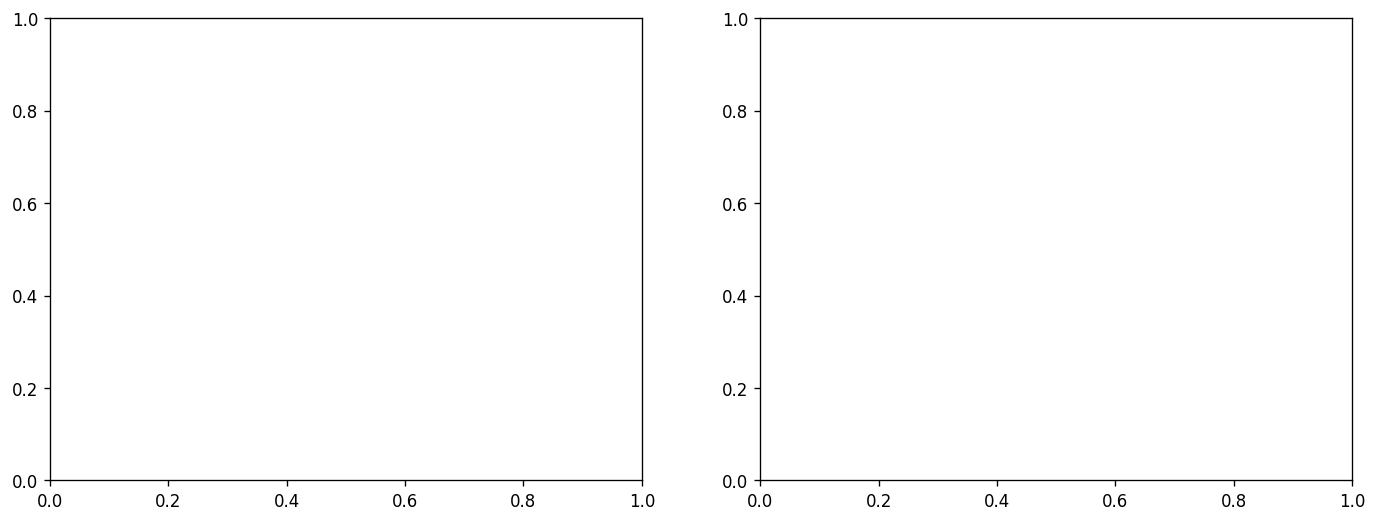

In [11]:
# === Visualisation reduction violation SLA ===
gnb_colors = {'Macro': '#9C27B0', 'Commerce': '#FF9800', 'Industrie': '#009688'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap reduction SLA par slice/gNB
pivot_red = df_sla.pivot(index='Slice', columns='gNB', values='Reduction_%')
sns.heatmap(pivot_red, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Reduction violation SLA (%)'})
axes[0].set_title('Reduction du taux de violation SLA\n(allocation statique → MILP optimale)',
                  fontweight='bold')

# Barplot violation avant/apres
x     = np.arange(len(SLICES))
width = 0.25
for i, gnb in enumerate(GNBS):
    sub_gnb = df_sla[df_sla['gNB'] == gnb].set_index('Slice').reindex(SLICES)
    vdef    = sub_gnb['Viol_statique_%'].values
    vopt    = sub_gnb['Viol_MILP_%'].values
    axes[1].bar(x + i*width, vdef, width, alpha=0.35, color=gnb_colors[gnb],
                label=f'{gnb} statique')
    axes[1].bar(x + i*width, vopt, width, alpha=0.9,  color=gnb_colors[gnb],
                label=f'{gnb} MILP', hatch='//')

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(SLICES)
axes[1].set_ylabel('Taux de violation SLA (%)')
axes[1].set_title('Violation SLA : statique vs MILP\npar gNB et slice', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle('Impact LSTM+MILP sur la violation SLA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'sla_violation_reduction.png', bbox_inches='tight')
plt.show()

## 9. Qualite de la prediction LSTM (latence -> p_pred vs p_reel)

In [ ]:
from scipy.stats import pearsonr

print('=== Correlation p_pred (latence LSTM) vs p_reel ===')
for stype in SLICES:
    pred_col = f'p_pred_{stype}'
    real_col = f'p_real_{stype}'
    pred_vals = df_all[pred_col].values
    real_vals = df_all[real_col].values
    mask      = ~(np.isnan(pred_vals) | np.isnan(real_vals))
    if mask.sum() > 10 and real_vals[mask].std() > 0:
        r, _ = pearsonr(real_vals[mask], pred_vals[mask])
        mae  = np.abs(pred_vals[mask] - real_vals[mask]).mean()
        print(f'  {stype:6s}  r = {r:+.4f}  MAE = {mae:.4f}')
    else:
        print(f'  {stype:6s}  pas assez de variance')

print()
print('=== rho_pred moyen par scenario ===')
print(df_all.groupby('scenario')[['rho_eMBB','rho_URLLC','rho_mMTC']].mean().round(3).to_string())


## 10. Visualisations

In [ ]:
scenario_order = [
    'NormalLoad', 'LowTrafficNight', 'FifaWorldCup_Commerce', 'KddiOutage_Storm',
    'SilverScrapes_Gaming', 'ClashLaunch_Sync', 'OverloadeMBB_Commerce',
    'OverloadURRLC_Industrie', 'IoTStorm_Industrie', 'GlobalSaturation',
    'SLABoundary_URLLC', 'HetLoad_Asymmetric_A', 'HetLoad_Asymmetric_B',
    'HetLoad_Asymmetric_C', 'HetLoad_FullDiversity', 'RampUp_Commerce',
    'FlashCrowd_Macro', 'PostEvent_Recovery', 'MECShared_Stress', 'EmergencyTraffic_URLLC'
]
scenario_order = [s for s in scenario_order if s in df_all['scenario'].unique()]
slice_colors   = {'eMBB': '#2196F3', 'URLLC': '#F44336', 'mMTC': '#4CAF50'}

# --- Heatmap gain ---
pivot = df_all.groupby(['scenario','gnb'])['gain_pct'].mean().reset_index()
pivot = pivot.pivot(index='scenario', columns='gnb', values='gain_pct')
pivot = pivot.reindex([s for s in scenario_order if s in pivot.index])

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            vmin=0, vmax=80, linewidths=0.5, linecolor='gray',
            ax=ax, cbar_kws={'label': 'Gain F(R) (%)'})
ax.set_title('Gain boucle fermee LSTM+MILP v2\n(prediction par latence)', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'closed_loop_v2_gain_heatmap.png', bbox_inches='tight')
plt.show()


In [ ]:
# --- Prediction vs reel (p_loss) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, stype in zip(axes, SLICES):
    pv = df_all[f'p_pred_{stype}'].values
    rv = df_all[f'p_real_{stype}'].values
    ax.scatter(rv, pv, color=slice_colors[stype], alpha=0.2, s=8)
    lim = max(rv.max(), pv.max()) * 1.05 + 0.01
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.5, linewidth=1.5, label='parfait')
    ax.set_xlabel('p_loss reelle')
    ax.set_ylabel('p_loss predite (via latence LSTM)')
    ax.set_title(f'{stype}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Qualite prediction LSTM v2 — p_loss via latence predite',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'closed_loop_v2_pred_quality.png', bbox_inches='tight')
plt.show()


In [ ]:
# --- F(R) temporel sur un scenario ---
fig, axes = plt.subplots(len(GNBS), 1, figsize=(14, 10), sharex=False)
for ax, gnb in zip(axes, GNBS):
    for sc_name, color in [('GlobalSaturation','red'), ('NormalLoad','green'),
                            ('SLABoundary_URLLC','orange'), ('RampUp_Commerce','purple')]:
        sub = df_all[(df_all['gnb'] == gnb) & (df_all['scenario'] == sc_name)].sort_values('t')
        if len(sub) == 0:
            continue
        ax.plot(sub['t'], sub['F_default'], '--', color=color, alpha=0.4, linewidth=1.5)
        ax.plot(sub['t'], sub['F_optimal'], '-',  color=color, linewidth=2.0, label=sc_name)
    ax.set_title(f'{gnb}', fontsize=10, fontweight='bold')
    ax.set_ylabel('F(R)')
    ax.set_ylim(-0.1, 2.2)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.legend(fontsize=8, ncol=2)
axes[-1].set_xlabel('Temps (s)')
plt.suptitle('F(R) defaut (--) vs optimal (-) — boucle fermee LSTM+MILP v2',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'closed_loop_v2_F_temporal.png', bbox_inches='tight')
plt.show()


In [ ]:
# --- Allocation RB dans le temps ---
fig, axes = plt.subplots(len(SLICES), 1, figsize=(14, 9))
gnb_show = 'Macro'
colors_sc = {'NormalLoad': 'green', 'GlobalSaturation': 'red',
             'SLABoundary_URLLC': 'orange', 'EmergencyTraffic_URLLC': 'purple'}
for ax, stype in zip(axes, SLICES):
    r_def = DEFAULT_RBS[gnb_show][stype]
    for sc_name, color in colors_sc.items():
        sub = df_all[(df_all['gnb'] == gnb_show) & (df_all['scenario'] == sc_name)].sort_values('t')
        if len(sub) == 0:
            continue
        ax.plot(sub['t'], sub[f'R_{stype}_opt'], '-o', color=color,
                markersize=4, linewidth=1.5, label=sc_name)
    ax.axhline(r_def, color='gray', linestyle='--', linewidth=1.5, label=f'Defaut ({r_def})')
    ax.set_ylabel(f'RBs {stype}')
    ax.set_ylim(0, R_MAX[gnb_show] + 2)
    ax.legend(fontsize=7, ncol=3)
axes[-1].set_xlabel('Temps (s)')
plt.suptitle(f'Allocation MILP en temps reel — {gnb_show}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'closed_loop_v2_rb_timeline.png', bbox_inches='tight')
plt.show()


## 11. Resume

In [ ]:
print('=== BOUCLE FERMEE v2 LSTM + MILP — RESUME ===')
print()
print(f'Fenetres simulees : {len(df_all):,}  |  Duree : {elapsed:.1f}s')
print()
print('Gain moyen par gNB :')
print(df_all.groupby('gnb')['gain_pct'].mean().round(2).to_string())
print()
print('Gain moyen par scenario :')
print(df_all.groupby('scenario')['gain_pct'].mean().sort_values(ascending=False).round(2).to_string())
print()
print('=== Comparaison plafond theorique vs boucle fermee ===')
print('  Plafond MILP parfait (rho reel) : Macro=70%, Commerce=55%, Industrie=46%')
print(f'  Boucle fermee LSTM+MILP        :',
      df_all.groupby('gnb')['gain_pct'].mean().round(1).to_dict())
